In [1]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point


In [2]:
import geopandas as gpd

path_county = Path("/Users/stevechiao/Desktop/程式作業/115_03/直轄市、縣(市)界線1140318")

county = gpd.read_file("/Users/stevechiao/Desktop/程式作業/115_03/直轄市、縣(市)界線1140318/COUNTY_MOI_1140318.shp", encoding="utf-8")

taipei_city = county[county["COUNTYNAME"] == "臺北市"]
print(taipei_city)

taipei = county[county["COUNTYNAME"] == "臺北市"]
taipei = taipei.to_crs("EPSG:4326")

  COUNTYID COUNTYCODE COUNTYNAME    COUNTYENG  \
7        A      63000        臺北市  Taipei City   

                                            geometry  
7  POLYGON ((121.57099 25.19717, 121.57098 25.197...  


In [3]:

# =========================
# 1. 設定資料夾路徑
# =========================
data_dir = Path("/Users/stevechiao/Desktop/程式作業/115_03/IDF-CC_臺北市_暴雨改變率")

# 抓所有符合的檔案
csv_files = sorted(data_dir.glob("IDF-CC_*.csv"))

print(f"找到 {len(csv_files)} 個 CSV 檔案")
for f in csv_files:
    print("-", f.name)


找到 10 個 CSV 檔案
- IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp45_第50百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp45_第5百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp45_第75百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp45_第95百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp85_第25百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp85_第50百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp85_第5百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp85_第75百分位.csv
- IDF-CC_臺北市_暴雨改變率_rcp85_第95百分位.csv


In [5]:
#print(Path.cwd())

/Users/stevechiao/Desktop/程式作業/115_03


In [4]:

# =========================
# 2. 解析檔名資訊
# =========================
def parse_filename(file_path: Path):
    """
    解析檔名，例如：
    IDF-CC_臺北市_暴雨改變率_rcp45_第95百分位.csv
    """
    name = file_path.stem
    pattern = r"IDF-CC_(.+?)_暴雨改變率_(rcp\d+)_第(\d+)百分位"
    match = re.match(pattern, name)

    if not match:
        raise ValueError(f"檔名格式不符：{file_path.name}")

    city = match.group(1)
    scenario = match.group(2).lower()
    percentile = int(match.group(3))

    return {
        "city": city,
        "scenario": scenario,
        "percentile": percentile,
    }






In [5]:
# =========================
# 3. 讀取單一檔案
# =========================
def read_idf_file(file_path: Path):
    meta = parse_filename(file_path)
    df = pd.read_csv(file_path)

    # 去除欄名空白
    df.columns = [c.strip() for c in df.columns]

    # 若經緯度欄名不是大寫，統一改成 LON / LAT
    rename_map = {}
    if "lon" in df.columns:
        rename_map["lon"] = "LON"
    if "lat" in df.columns:
        rename_map["lat"] = "LAT"
    df = df.rename(columns=rename_map)

    # 加 metadata
    df["city"] = meta["city"]
    df["scenario"] = meta["scenario"]
    df["percentile"] = meta["percentile"]
    df["source_file"] = file_path.name

    return df

In [6]:
# =========================
# 4. 全部讀進來
# =========================
data_dict = {}
all_dfs = []

for file_path in csv_files:
    meta = parse_filename(file_path)
    key = (meta["scenario"], meta["percentile"])

    df = read_idf_file(file_path)

    data_dict[key] = df
    all_dfs.append(df)

print(f"\n成功讀入 {len(all_dfs)} 個資料表")



成功讀入 10 個資料表


In [7]:
# =========================
# 5. 合併成一個大表
# =========================
combined_df = pd.concat(all_dfs, ignore_index=True)

print("\ncombined_df shape:", combined_df.shape)
print("\n欄位名稱：")
print(combined_df.columns.tolist())

print("\n前五列：")
print(combined_df.head())



combined_df shape: (220, 36)

欄位名稱：
['LON', 'LAT', 'rx1day_5yr', 'rx1day_10yr', 'rx1day_25yr', 'rx1day_75yr', 'rx1day_100yr', 'rx1day_200yr', 'rx2day_5yr', 'rx2day_10yr', 'rx2day_25yr', 'rx2day_75yr', 'rx2day_100yr', 'rx2day_200yr', 'rx3day_5yr', 'rx3day_10yr', 'rx3day_25yr', 'rx3day_75yr', 'rx3day_100yr', 'rx3day_200yr', 'rx4day_5yr', 'rx4day_10yr', 'rx4day_25yr', 'rx4day_75yr', 'rx4day_100yr', 'rx4day_200yr', 'rx5day_5yr', 'rx5day_10yr', 'rx5day_25yr', 'rx5day_75yr', 'rx5day_100yr', 'rx5day_200yr', 'city', 'scenario', 'percentile', 'source_file']

前五列：
      LON    LAT  rx1day_5yr  rx1day_10yr  rx1day_25yr  rx1day_75yr  \
0  121.45  25.15    7.121633     7.883415     6.397819     8.008169   
1  121.45  25.10    8.333606     8.076573    10.442720    11.200011   
2  121.50  25.05    9.795152    11.919066    10.873947    10.088372   
3  121.50  25.15    3.597776     1.758253     2.831490     2.173383   
4  121.50  25.10    8.540104     8.923438    10.235289    11.531365   

   rx1day_1

In [8]:
# =========================
# 6. 找出所有降雨欄位
# =========================
value_cols = [
    c for c in combined_df.columns
    if re.match(r"rx\d+day_\d+yr", c)
]

print("\n降雨欄位：")
print(value_cols)
print(f"共 {len(value_cols)} 個降雨欄位")


降雨欄位：
['rx1day_5yr', 'rx1day_10yr', 'rx1day_25yr', 'rx1day_75yr', 'rx1day_100yr', 'rx1day_200yr', 'rx2day_5yr', 'rx2day_10yr', 'rx2day_25yr', 'rx2day_75yr', 'rx2day_100yr', 'rx2day_200yr', 'rx3day_5yr', 'rx3day_10yr', 'rx3day_25yr', 'rx3day_75yr', 'rx3day_100yr', 'rx3day_200yr', 'rx4day_5yr', 'rx4day_10yr', 'rx4day_25yr', 'rx4day_75yr', 'rx4day_100yr', 'rx4day_200yr', 'rx5day_5yr', 'rx5day_10yr', 'rx5day_25yr', 'rx5day_75yr', 'rx5day_100yr', 'rx5day_200yr']
共 30 個降雨欄位


In [9]:
# =========================
# 7. wide -> long
# =========================
long_df = combined_df.melt(
    id_vars=["LON", "LAT", "city", "scenario", "percentile", "source_file"],
    value_vars=value_cols,
    var_name="metric",
    value_name="change_pct"
)

# 拆解 metric
metric_extract = long_df["metric"].str.extract(r"rx(\d+)day_(\d+)yr")
long_df["duration_day"] = metric_extract[0].astype(int)
long_df["return_period_yr"] = metric_extract[1].astype(int)

print("\nlong_df shape:", long_df.shape)
print(long_df.head())



long_df shape: (6600, 10)
      LON    LAT city scenario  percentile                        source_file  \
0  121.45  25.15  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
1  121.45  25.10  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
2  121.50  25.05  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
3  121.50  25.15  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
4  121.50  25.10  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   

       metric  change_pct  duration_day  return_period_yr  
0  rx1day_5yr    7.121633             1                 5  
1  rx1day_5yr    8.333606             1                 5  
2  rx1day_5yr    9.795152             1                 5  
3  rx1day_5yr    3.597776             1                 5  
4  rx1day_5yr    8.540104             1                 5  


In [10]:
# =========================
# 8. 建立巢狀資料結構
# =========================
nested_data = {}
for (scenario, percentile), df in data_dict.items():
    nested_data.setdefault(scenario, {})
    nested_data[scenario][percentile] = df

print("\n可用資料：")
for scenario in nested_data:
    print(scenario, sorted(nested_data[scenario].keys()))




可用資料：
rcp45 [5, 25, 50, 75, 95]
rcp85 [5, 25, 50, 75, 95]


In [11]:
# =========================
# 9. 輸出整理後檔案
# =========================
combined_df.to_csv(data_dir / "IDF_CC_combined_wide.csv", index=False, encoding="utf-8-sig")
long_df.to_csv(data_dir / "IDF_CC_combined_long.csv", index=False, encoding="utf-8-sig")

print("\n已輸出：")
print(data_dir / "IDF_CC_combined_wide.csv")
print(data_dir / "IDF_CC_combined_long.csv")


已輸出：
/Users/stevechiao/Desktop/程式作業/115_03/IDF-CC_臺北市_暴雨改變率/IDF_CC_combined_wide.csv
/Users/stevechiao/Desktop/程式作業/115_03/IDF-CC_臺北市_暴雨改變率/IDF_CC_combined_long.csv


In [21]:
print(long_df.head())
print(long_df.columns.tolist())
print(long_df.shape)

      LON    LAT city scenario  percentile                        source_file  \
0  121.45  25.15  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
1  121.45  25.10  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
2  121.50  25.05  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
3  121.50  25.15  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   
4  121.50  25.10  臺北市    rcp45          25  IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv   

       metric  change_pct  duration_day  return_period_yr  
0  rx1day_5yr    7.121633             1                 5  
1  rx1day_5yr    8.333606             1                 5  
2  rx1day_5yr    9.795152             1                 5  
3  rx1day_5yr    3.597776             1                 5  
4  rx1day_5yr    8.540104             1                 5  
['LON', 'LAT', 'city', 'scenario', 'percentile', 'source_file', 'metric', 'change_pct', 'duration_day', 'return_period_yr']
(6600, 10)


In [12]:


# 1. 依 scenario + percentile 做平均
summary_percentile = (
    long_df.groupby(["scenario", "percentile"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "percentile"])
)

print(summary_percentile)


# 2. 依 scenario + return period 做平均
summary_return = (
    long_df.groupby(["scenario", "return_period_yr"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "return_period_yr"])
)

print(summary_return)


# 3. 依 scenario + duration 做平均
summary_duration = (
    long_df.groupby(["scenario", "duration_day"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "duration_day"])
)

print(summary_duration)

  scenario  percentile  change_pct
0    rcp45           5  -11.285795
1    rcp45          25    7.563693
2    rcp45          50   21.806597
3    rcp45          75   44.176292
4    rcp45          95   97.194653
5    rcp85           5  -12.293304
6    rcp85          25    4.618133
7    rcp85          50   21.266162
8    rcp85          75   41.698429
9    rcp85          95   76.188124
   scenario  return_period_yr  change_pct
0     rcp45                 5   22.145722
1     rcp45                10   27.234006
2     rcp45                25   31.391116
3     rcp45                75   34.266270
4     rcp45               100   36.928452
5     rcp45               200   39.380961
6     rcp85                 5   20.638530
7     rcp85                10   22.910160
8     rcp85                25   25.950456
9     rcp85                75   27.785961
10    rcp85               100   29.462547
11    rcp85               200   31.025398
  scenario  duration_day  change_pct
0    rcp45             1   34.92

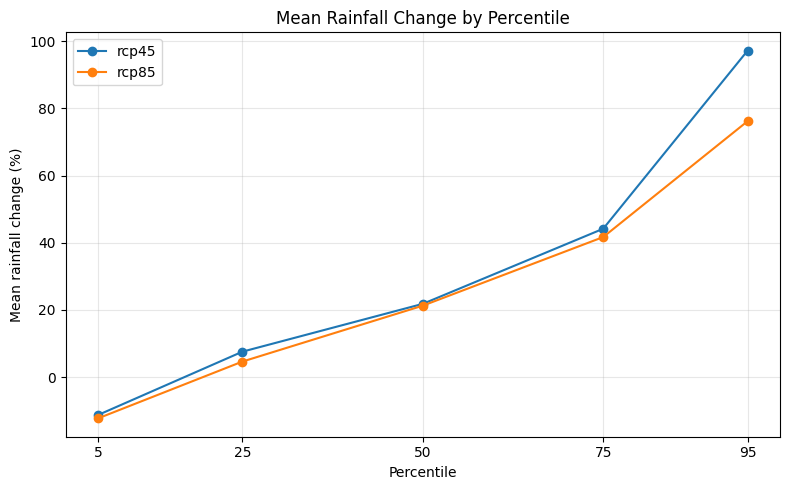

In [22]:

plt.figure(figsize=(8, 5))

for scenario in sorted(summary_percentile["scenario"].unique()):
    sub = summary_percentile[summary_percentile["scenario"] == scenario]
    plt.plot(
        sub["percentile"],
        sub["change_pct"],
        marker="o",
        label=scenario
    )

plt.xlabel("Percentile")
plt.ylabel("Mean rainfall change (%)")
plt.title("Mean Rainfall Change by Percentile")
plt.xticks([5, 25, 50, 75, 95])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Mean Rainfall Change by Percentile.png", dpi=300)
plt.show()

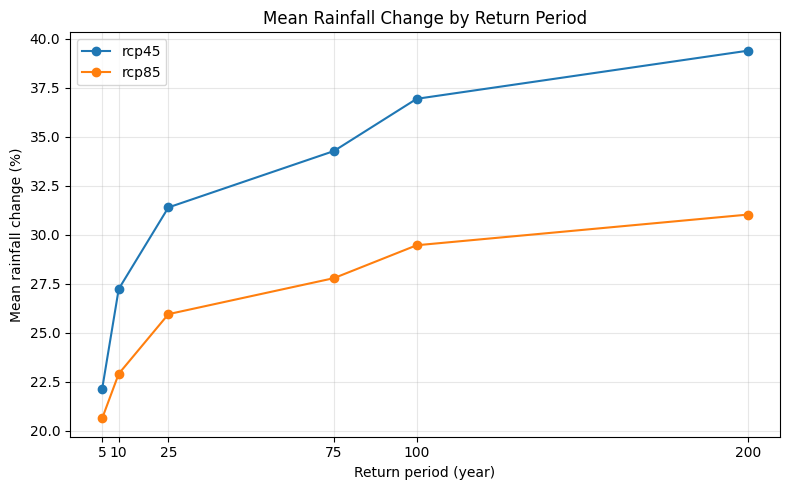

In [23]:
plt.figure(figsize=(8, 5))

for scenario in sorted(summary_return["scenario"].unique()):
    sub = summary_return[summary_return["scenario"] == scenario]
    plt.plot(
        sub["return_period_yr"],
        sub["change_pct"],
        marker="o",
        label=scenario
    )

plt.xlabel("Return period (year)")
plt.ylabel("Mean rainfall change (%)")
plt.title("Mean Rainfall Change by Return Period")
plt.xticks([5, 10, 25, 75, 100, 200])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Mean Rainfall Change by Return Period.png", dpi=300)
plt.show()

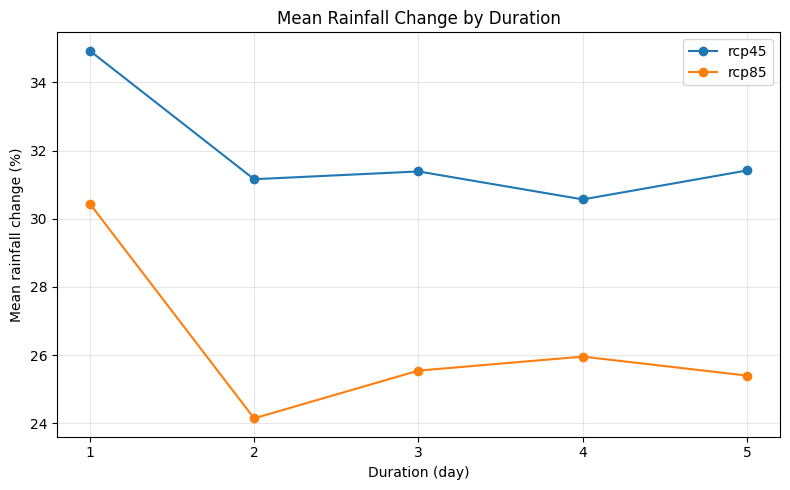

In [24]:
plt.figure(figsize=(8, 5))

for scenario in sorted(summary_duration["scenario"].unique()):
    sub = summary_duration[summary_duration["scenario"] == scenario]
    plt.plot(
        sub["duration_day"],
        sub["change_pct"],
        marker="o",
        label=scenario
    )

plt.xlabel("Duration (day)")
plt.ylabel("Mean rainfall change (%)")
plt.title("Mean Rainfall Change by Duration")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Mean Rainfall Change by Duration.png", dpi=300)
plt.show()

In [13]:
p95_df = long_df[long_df["percentile"] == 95]

summary_p95_return = (
    p95_df.groupby(["scenario", "return_period_yr"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "return_period_yr"])
)

summary_p95_duration = (
    p95_df.groupby(["scenario", "duration_day"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "duration_day"])
)

print(summary_p95_return)
print(summary_p95_duration)

   scenario  return_period_yr  change_pct
0     rcp45                 5   54.829210
1     rcp45                10   76.629436
2     rcp45                25   95.484153
3     rcp45                75  107.860776
4     rcp45               100  119.032379
5     rcp45               200  129.331961
6     rcp85                 5   55.123934
7     rcp85                10   62.922132
8     rcp85                25   73.845004
9     rcp85                75   81.345834
10    rcp85               100   88.506720
11    rcp85               200   95.385119
  scenario  duration_day  change_pct
0    rcp45             1  111.909886
1    rcp45             2   94.826788
2    rcp45             3   91.513177
3    rcp45             4   92.435029
4    rcp45             5   95.288382
5    rcp85             1   93.708022
6    rcp85             2   74.051048
7    rcp85             3   72.340230
8    rcp85             4   70.402488
9    rcp85             5   70.438832


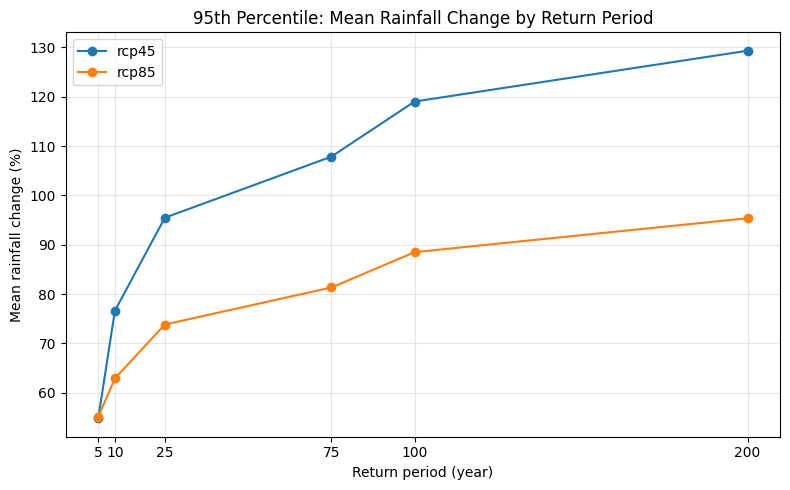

In [26]:
plt.figure(figsize=(8, 5))

for scenario in sorted(summary_p95_return["scenario"].unique()):
    sub = summary_p95_return[summary_p95_return["scenario"] == scenario]
    plt.plot(
        sub["return_period_yr"],
        sub["change_pct"],
        marker="o",
        label=scenario
    )

plt.xlabel("Return period (year)")
plt.ylabel("Mean rainfall change (%)")
plt.title("95th Percentile: Mean Rainfall Change by Return Period")
plt.xticks([5, 10, 25, 75, 100, 200])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("95th Percentile: Mean Rainfall Change by Return Period.png", dpi=300)
plt.show()

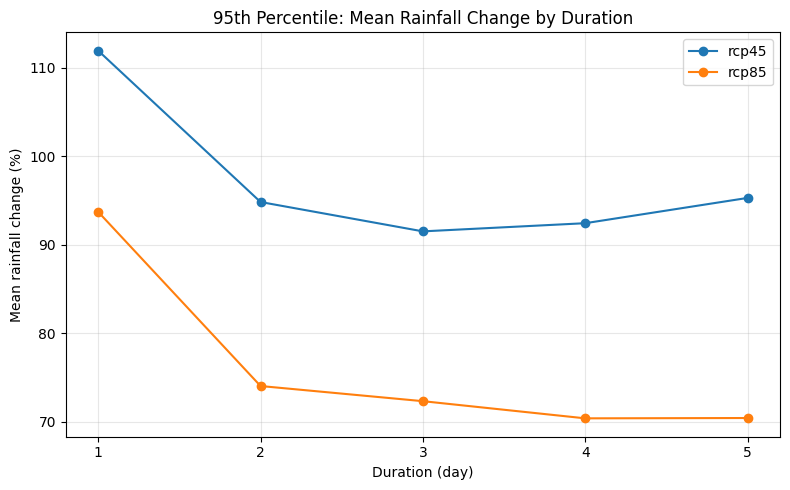

In [27]:
plt.figure(figsize=(8, 5))

for scenario in sorted(summary_p95_duration["scenario"].unique()):
    sub = summary_p95_duration[summary_p95_duration["scenario"] == scenario]
    plt.plot(
        sub["duration_day"],
        sub["change_pct"],
        marker="o",
        label=scenario
    )

plt.xlabel("Duration (day)")
plt.ylabel("Mean rainfall change (%)")
plt.title("95th Percentile: Mean Rainfall Change by Duration")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("95th Percentile: Mean Rainfall Change by Duration.png", dpi=300)
plt.show()

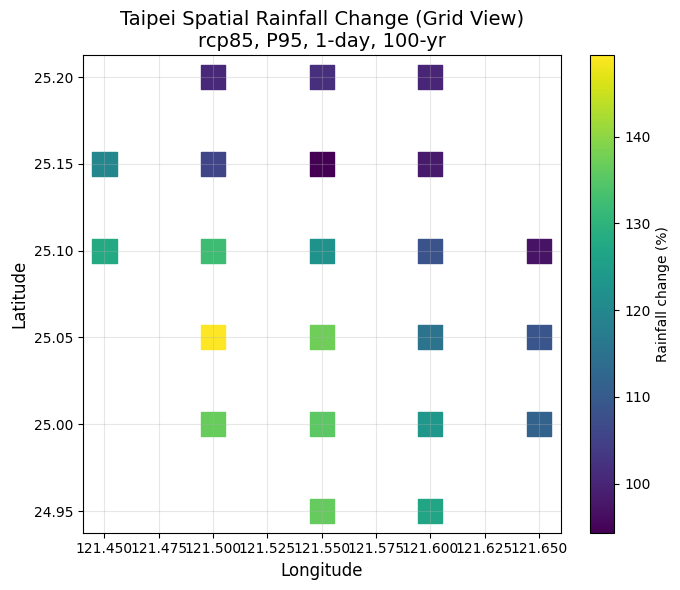

In [17]:
import matplotlib.pyplot as plt

# ===== 你可以改這裡 =====
target_scenario = "rcp85"
target_percentile = 95
target_duration = 1
target_return = 100
# ======================

map_df = long_df[
    (long_df["scenario"] == target_scenario) &
    (long_df["percentile"] == target_percentile) &
    (long_df["duration_day"] == target_duration) &
    (long_df["return_period_yr"] == target_return)
].copy()

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    map_df["LON"],
    map_df["LAT"],
    c=map_df["change_pct"],
    s=300,          # 點放大一點，看起來比較像網格
    marker="s",     # 方形
    cmap="viridis"
)

plt.colorbar(sc, label="Rainfall change (%)")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title(
    f"Taipei Spatial Rainfall Change (Grid View)\n"
    f"{target_scenario}, P{target_percentile}, {target_duration}-day, {target_return}-yr",
    fontsize=14
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"taipei_spatial_grid_{target_scenario}_p{target_percentile}_{target_duration}day_{target_return}yr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
from shapely.geometry import Point

map_df = long_df[
    (long_df["scenario"]=="rcp85") &
    (long_df["percentile"]==95) &
    (long_df["duration_day"]==1) &
    (long_df["return_period_yr"]==100)
].copy()

geometry = [Point(xy) for xy in zip(map_df["LON"], map_df["LAT"])]

rain_gdf = gpd.GeoDataFrame(
    map_df,
    geometry=geometry,
    crs="EPSG:4326"
)

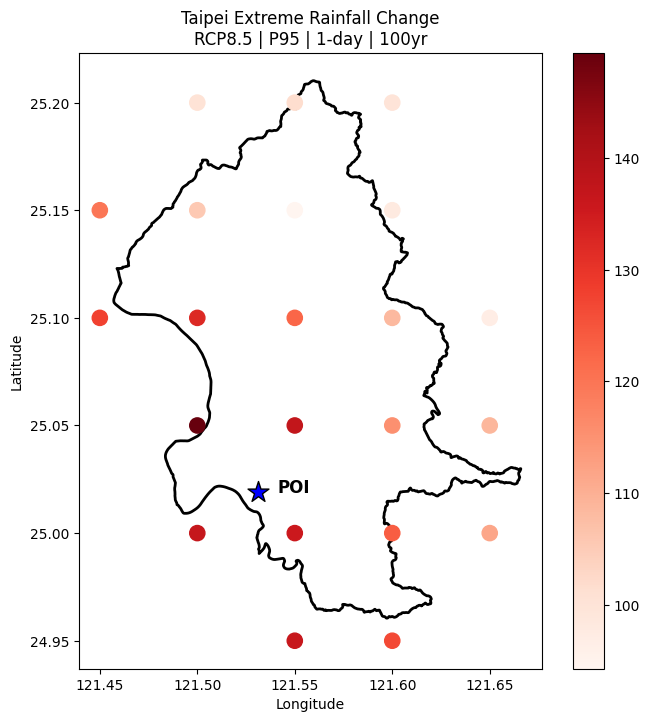

In [21]:
fig, ax = plt.subplots(figsize=(8,8))

# 畫台北市邊界
taipei.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=2
)

# 畫降雨變化
rain_gdf.plot(
    ax=ax,
    column="change_pct",
    cmap="Reds",
    legend=True,
    markersize=120
)

# ⭐ 加入你的關注位置
plt.scatter(
    poi_lon,
    poi_lat,
    color="blue",
    s=250,
    marker="*",
    edgecolor="black",
    label="Point of Interest"
)

plt.text(
    poi_lon + 0.01,
    poi_lat,
    "POI",
    fontsize=12,
    weight="bold"
)


plt.title("Taipei Extreme Rainfall Change\nRCP8.5 | P95 | 1-day | 100yr")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [20]:
# 關注位置 (POI)
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

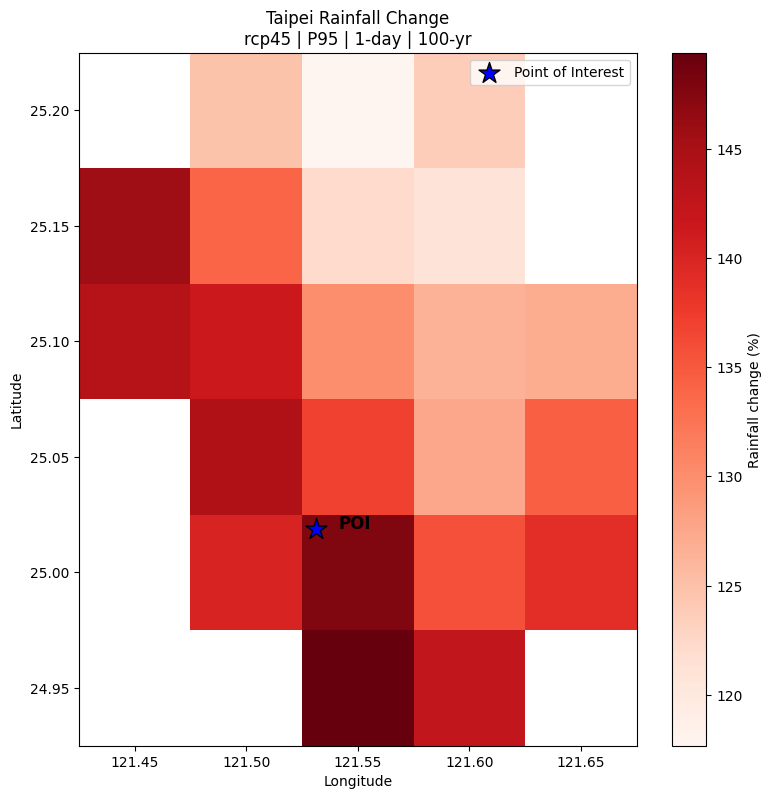

In [22]:
# ===== 你可以改這裡 =====

scenario = "rcp45"
percentile = 95
duration_day = 1
return_period = 100

map_df = long_df[
    (long_df["scenario"] == scenario) &
    (long_df["percentile"] == percentile) &
    (long_df["duration_day"] == duration_day) &
    (long_df["return_period_yr"] == return_period)
].copy()

import numpy as np

lon_vals = np.sort(map_df["LON"].unique())
lat_vals = np.sort(map_df["LAT"].unique())

grid = map_df.pivot_table(
    index="LAT",
    columns="LON",
    values="change_pct"
)

lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

import matplotlib.pyplot as plt

plt.figure(figsize=(9,9))



plt.pcolormesh(
    lon_grid,
    lat_grid,
    grid.values,
    cmap="Reds",
    shading="auto"
)

plt.colorbar(label="Rainfall change (%)")

 #畫台北市邊界
taipei.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=2
)

plt.scatter(
    poi_lon,
    poi_lat,
    color="blue",
    s=250,
    marker="*",
    edgecolor="black",
    label="Point of Interest"
)

plt.text(
    poi_lon + 0.01,
    poi_lat,
    "POI",
    fontsize=12,
    weight="bold"
)

plt.title(
    f"Taipei Rainfall Change\n"
    f"{scenario} | P{percentile} | {duration_day}-day | {return_period}-yr"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()
plt.show()

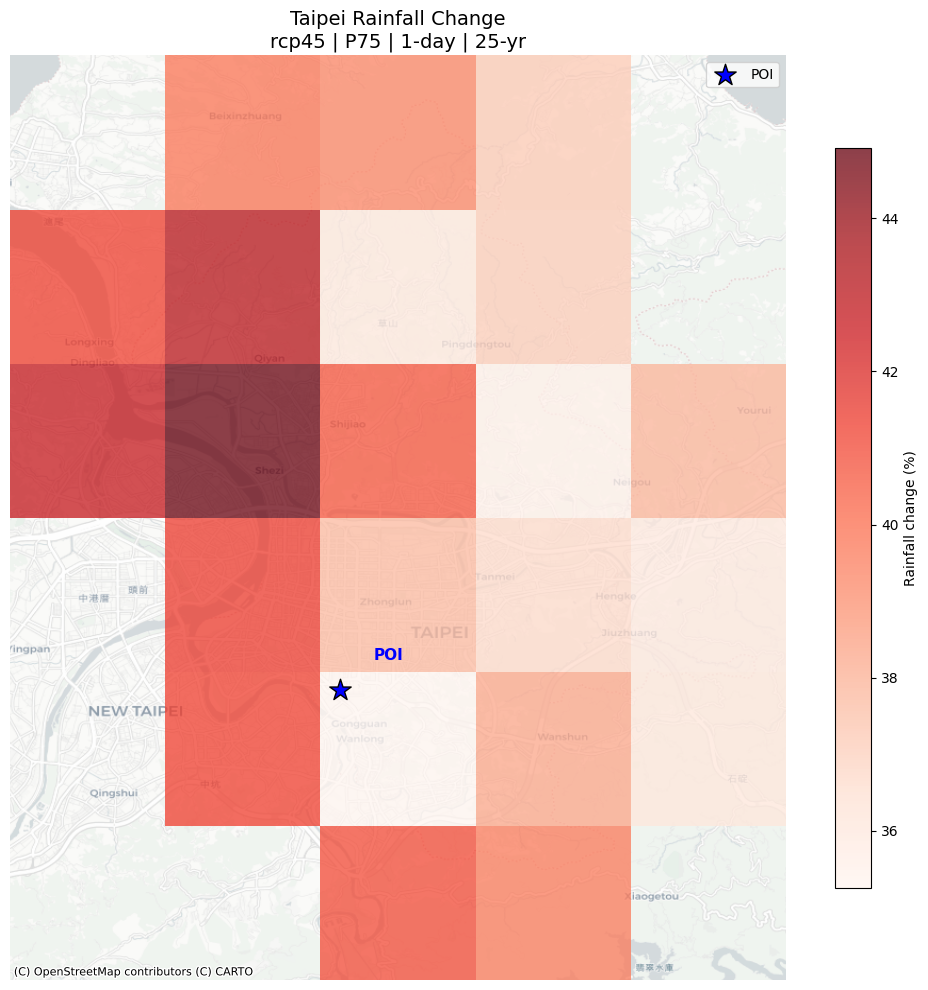

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# =========================================================
# 1. 可調參數：之後只改這裡
# =========================================================
scenario = "rcp45"      # "rcp45" or "rcp85"
percentile = 75         # 5, 25, 50, 75, 95
duration_day = 1        # 1, 2, 3, 4, 5
return_period = 25     # 5, 10, 25, 75, 100, 200

# 色階可自己調；若不想固定，改成 None
#vmin = 120
#vmax = 150

# 底圖樣式可改：
# ctx.providers.OpenStreetMap.Mapnik
# ctx.providers.CartoDB.Positron
# ctx.providers.CartoDB.Voyager
basemap_source = ctx.providers.CartoDB.Positron

# =========================================================
# 2. 關注位置（POI）
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# =========================================================
# 3. 篩選資料
# =========================================================
map_df = long_df[
    (long_df["scenario"] == scenario) &
    (long_df["percentile"] == percentile) &
    (long_df["duration_day"] == duration_day) &
    (long_df["return_period_yr"] == return_period)
].copy()

if map_df.empty:
    raise ValueError("這組條件沒有資料，請檢查 scenario / percentile / duration_day / return_period。")

# =========================================================
# 4. 建立 GeoDataFrame 並轉成 Web Mercator (EPSG:3857)
# =========================================================
gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df["LON"], map_df["LAT"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# POI 也轉投影
poi_gdf = gpd.GeoDataFrame(
    {"name": ["POI"]},
    geometry=[Point(poi_lon, poi_lat)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# 取轉投影後的 x/y
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y
poi_x = poi_gdf.geometry.x.iloc[0]
poi_y = poi_gdf.geometry.y.iloc[0]

# =========================================================
# 5. 建立格點矩陣
# =========================================================
x_vals = np.sort(gdf["x"].unique())
y_vals = np.sort(gdf["y"].unique())

grid = gdf.pivot_table(
    index="y",
    columns="x",
    values="change_pct"
).sort_index(ascending=True)

# 對齊 x / y
x_vals = grid.columns.values
y_vals = grid.index.values
Z = grid.values

# =========================================================
# 6. 從中心點推估格點邊界（給 pcolormesh 用）
# =========================================================
def centers_to_edges(vals):
    vals = np.asarray(vals)
    diffs = np.diff(vals)
    if len(diffs) == 0:
        # 只有一個點時，隨便給小範圍
        step = 1000
        return np.array([vals[0] - step/2, vals[0] + step/2])
    edges = np.empty(len(vals) + 1)
    edges[1:-1] = (vals[:-1] + vals[1:]) / 2
    edges[0] = vals[0] - diffs[0] / 2
    edges[-1] = vals[-1] + diffs[-1] / 2
    return edges

x_edges = centers_to_edges(x_vals)
y_edges = centers_to_edges(y_vals)

# =========================================================
# 7. 畫圖
# =========================================================
fig, ax = plt.subplots(figsize=(10, 10))

mesh = ax.pcolormesh(
    x_edges,
    y_edges,
    Z,
    cmap="Reds",
    shading="auto",
    #vmin=vmin,
   # vmax=vmax,
    alpha=0.75
)

# 加底圖
ctx.add_basemap(
    ax,
    source=basemap_source,
    crs="EPSG:3857"
)

# 畫 POI
ax.scatter(
    poi_x,
    poi_y,
    color="blue",
    marker="*",
    s=260,
    edgecolor="black",
    linewidth=1.0,
    zorder=5,
    label="POI"
)

ax.text(
    poi_x + 1200,
    poi_y + 1200,
    "POI",
    fontsize=11,
    weight="bold",
    color="blue",
    zorder=6
)

# colorbar
cbar = plt.colorbar(mesh, ax=ax, shrink=0.8)
cbar.set_label("Rainfall change (%)")

# 標題
ax.set_title(
    f"Taipei Rainfall Change\n"
    f"{scenario} | P{percentile} | {duration_day}-day | {return_period}-yr",
    fontsize=14
)

ax.legend(loc="upper right")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Taipei Rainfall Change＿45_751-25-_Daxue.png", dpi=300)
plt.show()

In [ ]:
#針對大學里所在格點做細部分析

In [26]:
target_lat = 25.00
target_lon = 121.55

point_df = long_df[
    (long_df["LAT"] == target_lat) &
    (long_df["LON"] == target_lon)
].copy()

print(point_df.shape)
print(point_df.head())

(300, 10)
        LON   LAT city scenario  percentile  \
9    121.55  25.0  臺北市    rcp45          25   
33   121.55  25.0  臺北市    rcp45          50   
56   121.55  25.0  臺北市    rcp45           5   
78   121.55  25.0  臺北市    rcp45          75   
100  121.55  25.0  臺北市    rcp45          95   

                           source_file      metric  change_pct  duration_day  \
9    IDF-CC_臺北市_暴雨改變率_rcp45_第25百分位.csv  rx1day_5yr   10.313126             1   
33   IDF-CC_臺北市_暴雨改變率_rcp45_第50百分位.csv  rx1day_5yr   19.320733             1   
56    IDF-CC_臺北市_暴雨改變率_rcp45_第5百分位.csv  rx1day_5yr   -3.642080             1   
78   IDF-CC_臺北市_暴雨改變率_rcp45_第75百分位.csv  rx1day_5yr   27.775588             1   
100  IDF-CC_臺北市_暴雨改變率_rcp45_第95百分位.csv  rx1day_5yr   56.196226             1   

     return_period_yr  
9                   5  
33                  5  
56                  5  
78                  5  
100                 5  


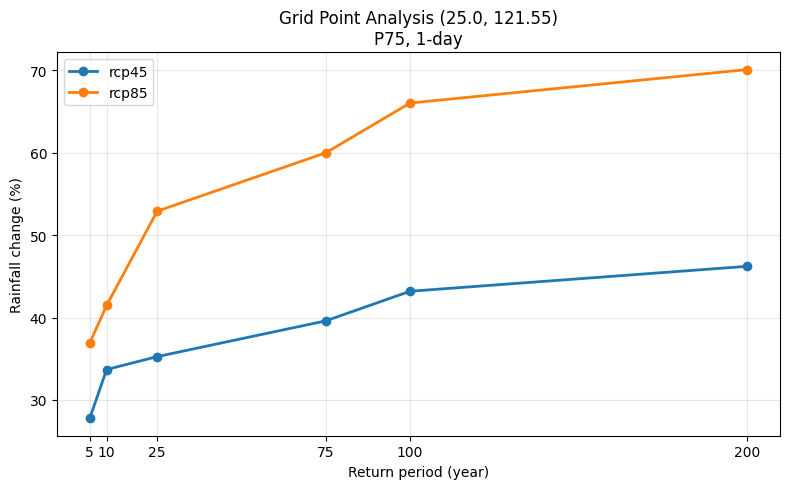

In [40]:
# 可自行改條件
sel_percentile = 75
sel_duration = 1

sub = point_df[
    (point_df["percentile"] == sel_percentile) &
    (point_df["duration_day"] == sel_duration)
].copy()

summary_point_return = (
    sub.groupby(["scenario", "return_period_yr"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "return_period_yr"])
)

plt.figure(figsize=(8, 5))

for scenario in sorted(summary_point_return["scenario"].unique()):
    ss = summary_point_return[summary_point_return["scenario"] == scenario]
    plt.plot(
        ss["return_period_yr"],
        ss["change_pct"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.xlabel("Return period (year)")
plt.ylabel("Rainfall change (%)")
plt.title(f"Grid Point Analysis ({target_lat}, {target_lon})\nP{sel_percentile}, {sel_duration}-day")
plt.xticks([5, 10, 25, 75, 100, 200])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

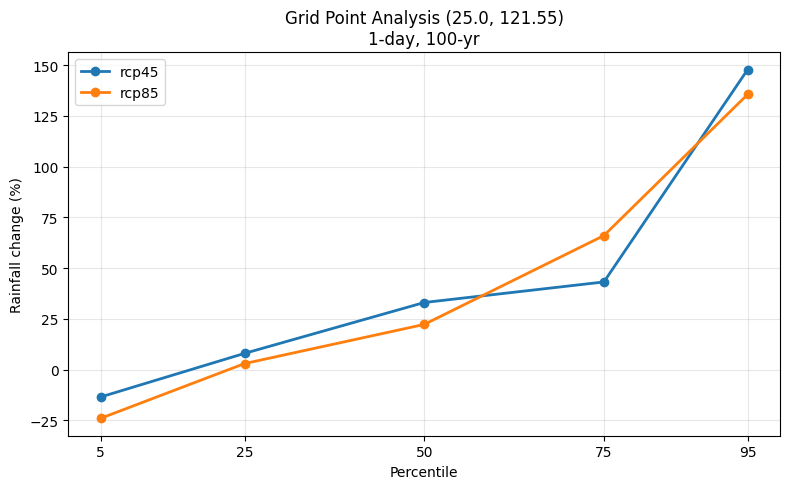

In [37]:
sel_duration = 1
sel_return_period = 100

sub = point_df[
    (point_df["duration_day"] == sel_duration) &
    (point_df["return_period_yr"] == sel_return_period)
].copy()

summary_point_percentile = (
    sub.groupby(["scenario", "percentile"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "percentile"])
)

plt.figure(figsize=(8, 5))

for scenario in sorted(summary_point_percentile["scenario"].unique()):
    ss = summary_point_percentile[summary_point_percentile["scenario"] == scenario]
    plt.plot(
        ss["percentile"],
        ss["change_pct"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.xlabel("Percentile")
plt.ylabel("Rainfall change (%)")
plt.title(f"Grid Point Analysis ({target_lat}, {target_lon})\n{sel_duration}-day, {sel_return_period}-yr")
plt.xticks([5, 25, 50, 75, 95])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

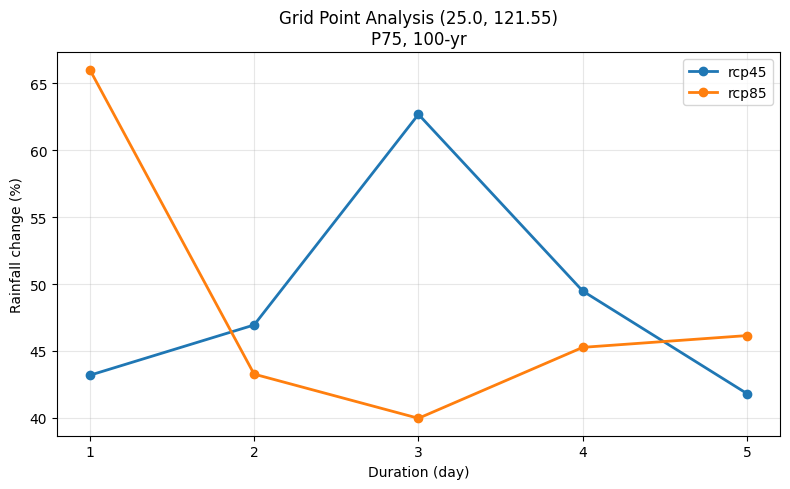

In [39]:
sel_percentile = 75
sel_return_period = 100

sub = point_df[
    (point_df["percentile"] == sel_percentile) &
    (point_df["return_period_yr"] == sel_return_period)
].copy()

summary_point_duration = (
    sub.groupby(["scenario", "duration_day"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "duration_day"])
)

plt.figure(figsize=(8, 5))

for scenario in sorted(summary_point_duration["scenario"].unique()):
    ss = summary_point_duration[summary_point_duration["scenario"] == scenario]
    plt.plot(
        ss["duration_day"],
        ss["change_pct"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.xlabel("Duration (day)")
plt.ylabel("Rainfall change (%)")
plt.title(f"Grid Point Analysis ({target_lat}, {target_lon})\nP{sel_percentile}, {sel_return_period}-yr")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

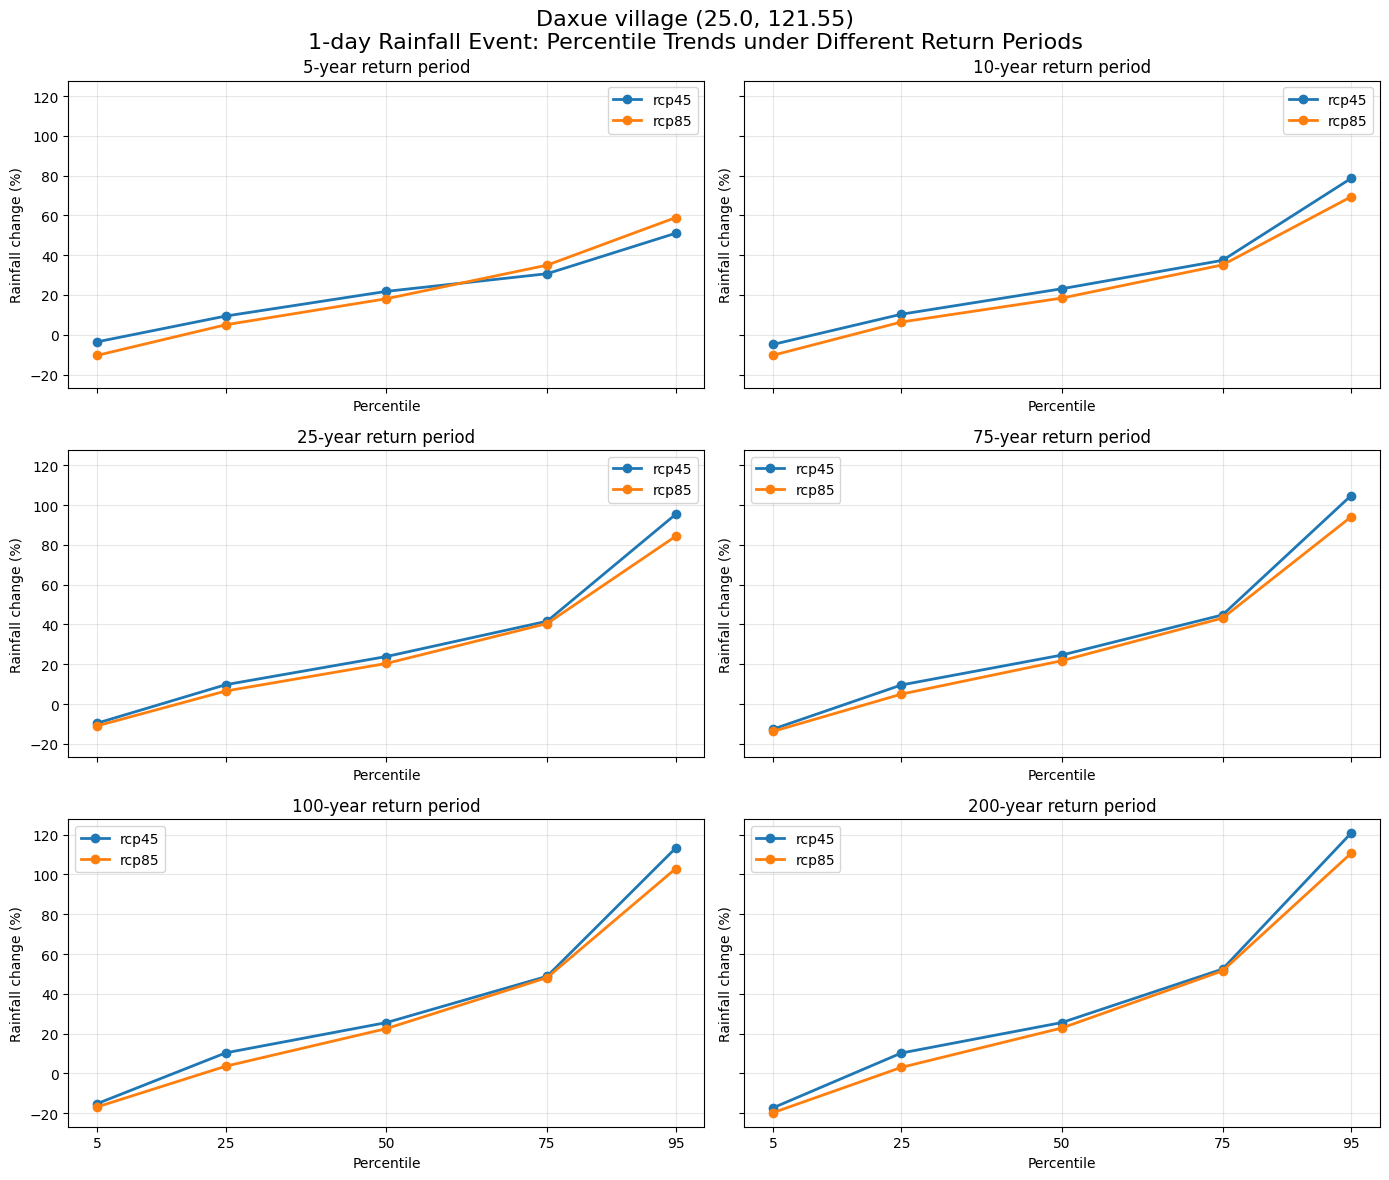

In [28]:
# 六個 return periods
return_period_list = [5, 10, 25, 75, 100, 200]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, rp in zip(axes, return_period_list):
    sub = point_df[point_df["return_period_yr"] == rp].copy()

    for scenario in ["rcp45", "rcp85"]:
        ss = (
            sub[sub["scenario"] == scenario]
            .groupby("percentile", as_index=False)["change_pct"]
            .mean()
            .sort_values("percentile")
        )

        ax.plot(
            ss["percentile"],
            ss["change_pct"],
            marker="o",
            linewidth=2,
            label=scenario
        )

    ax.set_title(f"{rp}-year return period")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Rainfall change (%)")
    ax.set_xticks([5, 25, 50, 75, 95])
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(
    f"Daxue village ({target_lat}, {target_lon})\n"
    f"1-day Rainfall Event: Percentile Trends under Different Return Periods",
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.savefig("Daxue_1-day Rainfall Event: Percentile Trends under Different Return Periods.png", dpi=300)
plt.show()

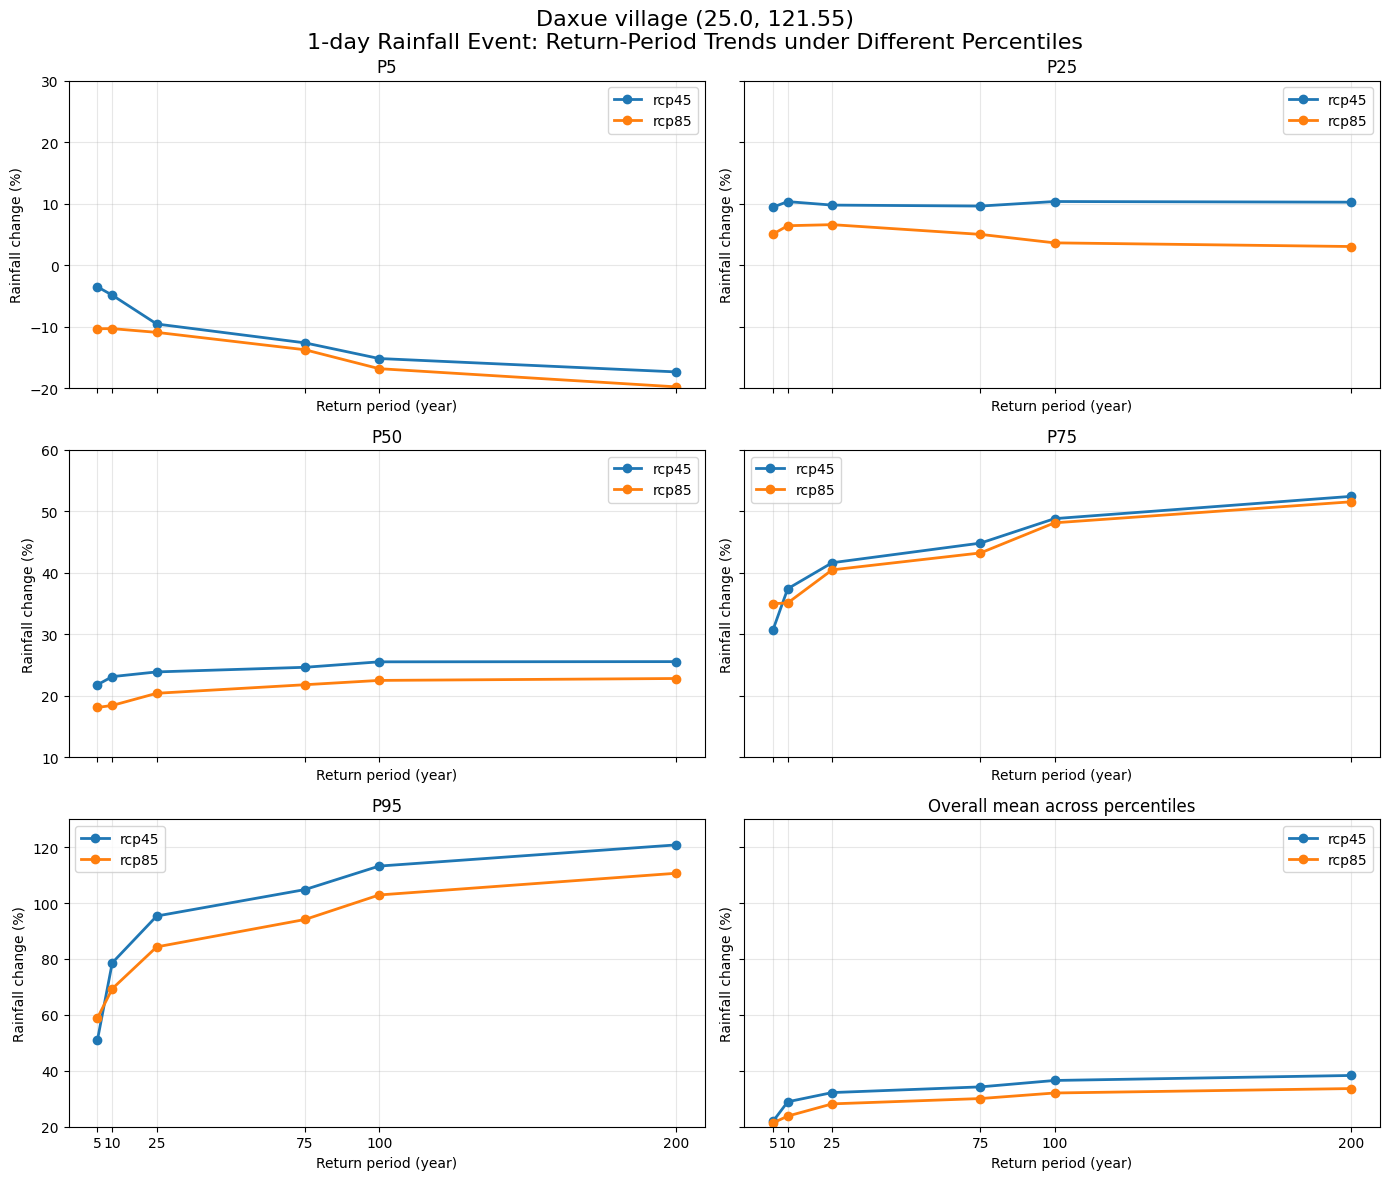

In [29]:
percentile_list = [5, 25, 50, 75, 95]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey='row')
axes = axes.flatten()

# 前五張：各 percentile
for i, p in enumerate(percentile_list):
    ax = axes[i]
    sub = point_df[point_df["percentile"] == p].copy()

    for scenario in ["rcp45", "rcp85"]:
        ss = (
            sub[sub["scenario"] == scenario]
            .groupby("return_period_yr", as_index=False)["change_pct"]
            .mean()
            .sort_values("return_period_yr")
        )

        ax.plot(
            ss["return_period_yr"],
            ss["change_pct"],
            marker="o",
            linewidth=2,
            label=scenario
        )

    ax.set_title(f"P{p}")
    ax.set_xlabel("Return period (year)")
    ax.set_ylabel("Rainfall change (%)")
    ax.set_xticks([5, 10, 25, 75, 100, 200])
    ax.grid(True, alpha=0.3)
    ax.legend()

# 第六張：overall mean
ax = axes[5]
overall = (
    point_df.groupby(["scenario", "return_period_yr"], as_index=False)["change_pct"]
    .mean()
    .sort_values(["scenario", "return_period_yr"])
)

for scenario in ["rcp45", "rcp85"]:
    ss = overall[overall["scenario"] == scenario]
    ax.plot(
        ss["return_period_yr"],
        ss["change_pct"],
        marker="o",
        linewidth=2,
        label=scenario
    )


# Row 1
axes[0].set_ylim(-20,30)
axes[1].set_ylim(-20,30)

# Row 2
axes[2].set_ylim(10,60)
axes[3].set_ylim(10,60)

# Row 3
axes[4].set_ylim(20,130)
axes[5].set_ylim(20,130)


ax.set_title("Overall mean across percentiles")
ax.set_xlabel("Return period (year)")
ax.set_ylabel("Rainfall change (%)")
ax.set_xticks([5, 10, 25, 75, 100, 200])
ax.grid(True, alpha=0.3)
ax.legend()

fig.suptitle(
    f"Daxue village ({target_lat}, {target_lon})\n"
    f"1-day Rainfall Event: Return-Period Trends under Different Percentiles",
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.savefig("Daxue_1-day Rainfall Event: Return-Period Trends under Different Percentiles.png", dpi=300)
plt.show()

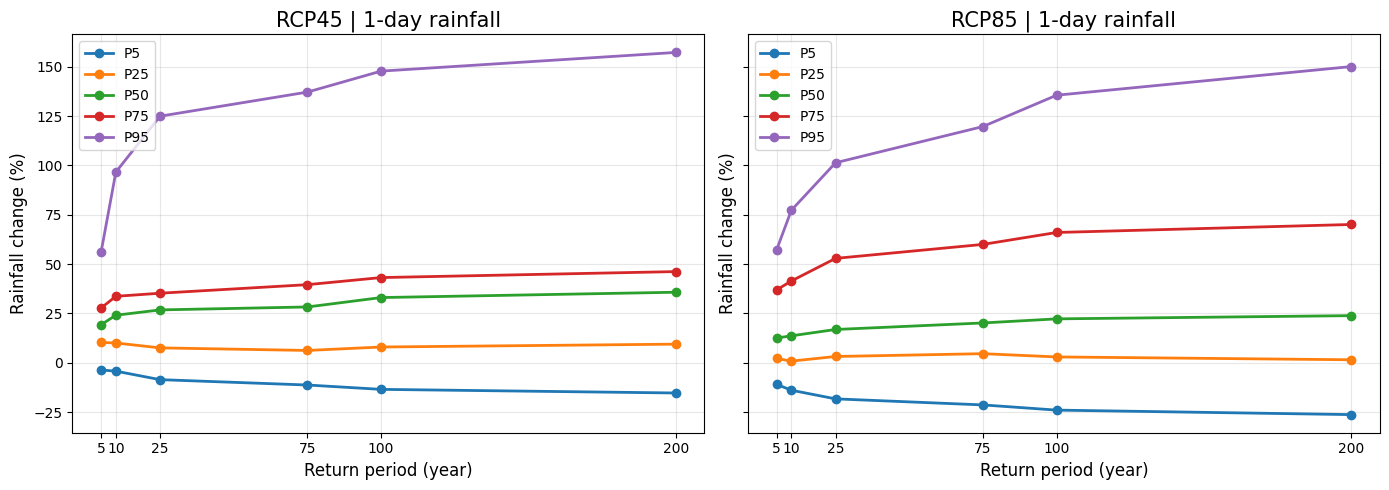

In [30]:
target_lat = 25.00
target_lon = 121.55
target_duration = 1


point_df = long_df[
    (long_df["LAT"] == target_lat) &
    (long_df["LON"] == target_lon) &
    (long_df["duration_day"] == target_duration)
].copy()

percentile_list = [5, 25, 50, 75, 95]

# 建立兩張圖：rcp45、rcp85
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, scenario in zip(axes, ["rcp45", "rcp85"]):
    sub = point_df[point_df["scenario"] == scenario].copy()

    for p in percentile_list:
        ss = (
            sub[sub["percentile"] == p]
            .groupby("return_period_yr", as_index=False)["change_pct"]
            .mean()
            .sort_values("return_period_yr")
        )

        ax.plot(
            ss["return_period_yr"],
            ss["change_pct"],
            marker="o",
            linewidth=2,
            label=f"P{p}"
        )

    ax.set_title(f"{scenario.upper()} | 1-day rainfall", fontsize=15)
    ax.set_xlabel("Return period (year)", fontsize=12)
    ax.set_ylabel("Rainfall change (%)", fontsize=12)
    ax.set_xticks([5, 10, 25, 75, 100, 200])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("rcp_1dayrainfall_percompare.png", dpi=300)
plt.savefig("Daxue_rcp_1dayrainfall_percompare.png", dpi=300)
plt.show()

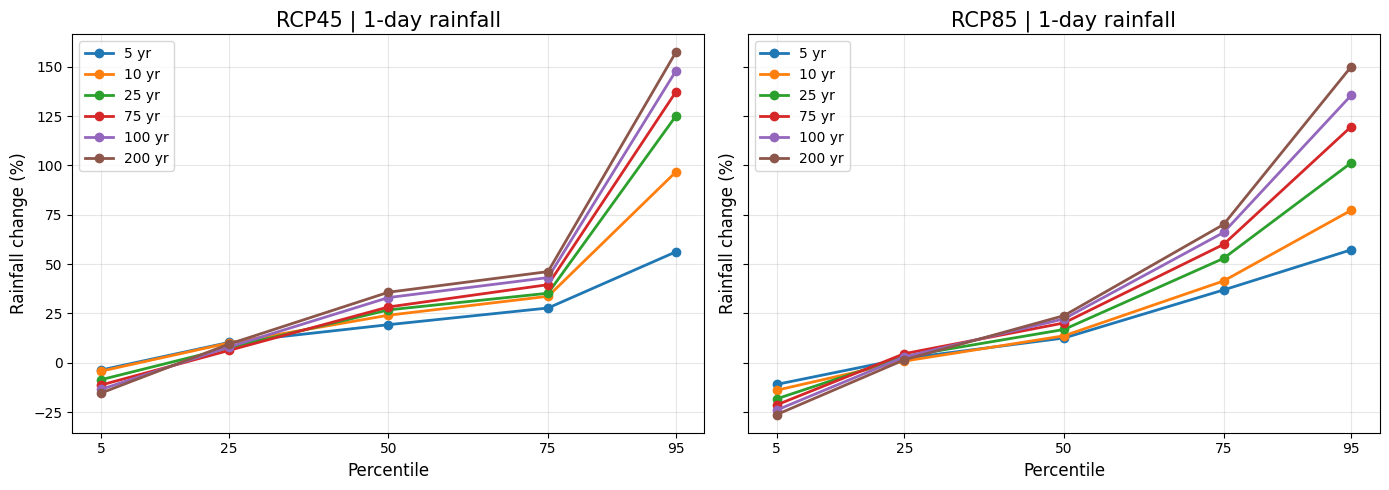

In [31]:
point_df = long_df[
    (long_df["LAT"] == target_lat) &
    (long_df["LON"] == target_lon) &
    (long_df["duration_day"] == target_duration)
].copy()

return_period_list = [5, 10, 25, 75, 100, 200]

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for ax, scenario in zip(axes, ["rcp45","rcp85"]):

    sub = point_df[point_df["scenario"] == scenario]

    for rp in return_period_list:

        ss = (
            sub[sub["return_period_yr"] == rp]
            .groupby("percentile", as_index=False)["change_pct"]
            .mean()
            .sort_values("percentile")
        )

        ax.plot(
            ss["percentile"],
            ss["change_pct"],
            marker="o",
            linewidth=2,
            label=f"{rp} yr"
        )

    ax.set_title(f"{scenario.upper()} | 1-day rainfall", fontsize=15)
    ax.set_xlabel("Percentile", fontsize=12)
    ax.set_ylabel("Rainfall change (%)", fontsize=12)
    ax.set_xticks([5,25,50,75,95])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("Daxue_rcp_1dayrainfall_yrcompare.png", dpi=300)
plt.show()